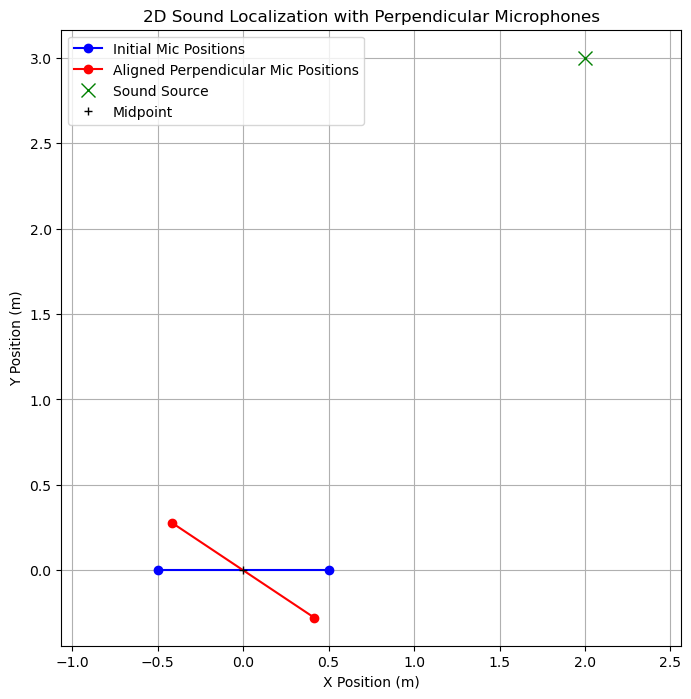

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram
from IPython.display import Audio

# Microphone positions
mic1_initial = np.array([-0.5, 0])   # Mic 1 at [-1, 0]
mic2_initial = np.array([0.5, 0])    # Mic 2 at [1, 0]
mic_distance = np.linalg.norm(mic2_initial - mic1_initial)  # Distance between microphones
midpoint = (mic1_initial + mic2_initial) / 2  # Midpoint between mic 1 and mic 2

# Sound source position
sound_source = np.array([2, 3])  # Initial sound source position for alignment

# Angle from midpoint to sound source

angle_diff = -np.arctan2(sound_source[0] - midpoint[0], sound_source[1] - midpoint[1])


# Function to rotate microphones and calculate alignment loss
def mic_rotation(angle_to_rotate, sound_source, midpoint):
    mic1_rotated = midpoint + (mic_distance / 2) * np.array([np.cos(angle_to_rotate), np.sin(angle_to_rotate)])
    mic2_rotated = midpoint + (-mic_distance / 2) * np.array([np.cos(angle_to_rotate), np.sin(angle_to_rotate)])

    return mic1_rotated, mic2_rotated

mic1_rotated, mic2_rotated = mic_rotation(angle_diff, sound_source, midpoint)
# Plotting the initial and aligned microphone positions
plt.figure(figsize=(8, 8))
plt.plot([mic1_initial[0], mic2_initial[0]], [mic1_initial[1], mic2_initial[1]], 'bo-', label="Initial Mic Positions")
plt.plot([mic1_rotated[0], mic2_rotated[0]], [mic1_rotated[1], mic2_rotated[1]], 'ro-', label="Aligned Perpendicular Mic Positions")
plt.plot(sound_source[0], sound_source[1], 'gx', label="Sound Source", markersize=10)
plt.plot(midpoint[0], midpoint[1], 'k+', label="Midpoint")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("2D Sound Localization with Perpendicular Microphones")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

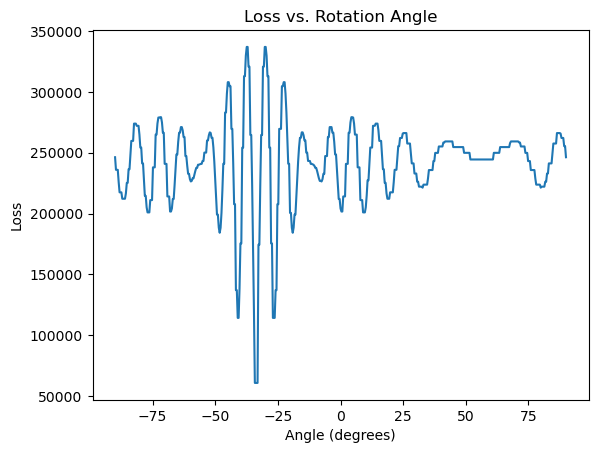

Rotated Microphone Positions (Perpendicular):
Mic 1: [ 0.41602515 -0.2773501 ]
Mic 2: [-0.41602515  0.2773501 ]


In [29]:
# Load audio file and display it
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import spectrogram
from IPython.display import Audio
from scipy import signal

folder_path = r'Bird_sound'
filename = "Bird_call.wav"
file_path = os.path.join(folder_path, filename)

SR, y = wavfile.read(file_path)
display(Audio(y, rate=SR))

# Constants for loss calculation
SOUND_SPEED = 343.2
  # Updated sound source position
y1_all = []
y2_all = []
# Loss calculation function for a range of angles
def loss_angle(angle_to_rotate):
    mic1_rotated, mic2_rotated = mic_rotation(angle_to_rotate, sound_source, midpoint)

    dist_to_mic1 = np.linalg.norm(sound_source - mic1_rotated)
    dist_to_mic2 = np.linalg.norm(sound_source - mic2_rotated)
    
    t_to_mic1 = dist_to_mic1 / SOUND_SPEED
    t_to_mic2 = dist_to_mic2 / SOUND_SPEED
    
    samples_at_mic1 = int(t_to_mic1 * SR)
    samples_at_mic2 = int(t_to_mic2 * SR)
    
    y1 = y[samples_at_mic1:-samples_at_mic2]
    y2 = y[samples_at_mic2:-samples_at_mic1]

    sos = signal.butter(1, 500, 'lp', fs=SR, output='sos')
    y1 = signal.sosfilt(sos, y1)
    y2 = signal.sosfilt(sos, y2)

    y1_all.append(y1)
    y2_all.append(y2)
    
    # Calculate the loss
    loss = np.linalg.norm(y1 - y2)
    return loss

# Calculate and plot loss for a range of angles
angles = np.linspace(-np.pi/2, np.pi/2, 501)
losses = np.array([loss_angle(a) for a in angles])


sos = signal.butter(1, 3.5, 'lp', fs=1/(np.pi/101), output='sos')
sig = signal.sosfilt(sos, losses)

plt.figure()
plt.plot(np.degrees(angles), losses)
# plt.plot(np.degrees(angles), sig)
plt.xlabel("Angle (degrees)")
plt.ylabel("Loss")
plt.title("Loss vs. Rotation Angle")
plt.show()

# Display the final rotated microphone positions
print("Rotated Microphone Positions (Perpendicular):")
print("Mic 1:", mic1_rotated)
print("Mic 2:", mic2_rotated)



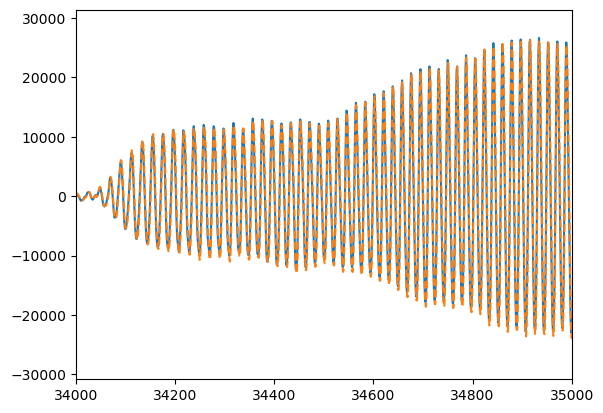

48000


In [11]:
sos = signal.butter(1, 500, 'lp', fs=SR, output='sos')
y1 = signal.sosfilt(sos, y)

plt.figure()
# plt.plot(y)
plt.plot(y-y1)
plt.plot(y,'--')
plt.xlim([34000,35000])

plt.show()

print(SR)